# ISIC 2019 Metadata EDA and Fairness Audit

This notebook analyzes the ISIC 2019 metadata and labels using **age** and **sex** as the fairness attributes.

We intentionally do **not** use anatomical site in this EDA. Images are not required.

In [16]:
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

## Load Metadata and Labels

In [17]:
TRAIN_META_PATH = PROJECT_ROOT / "ISIC_2019_Training_Metadata.csv"
TEST_META_PATH = PROJECT_ROOT / "ISIC_2019_Test_Metadata.csv"
TRAIN_GT_PATH = PROJECT_ROOT / "ISIC_2019_Training_GroundTruth.csv"
TEST_GT_PATH = PROJECT_ROOT / "ISIC_2019_Test_GroundTruth.csv"

train_meta = pd.read_csv(TRAIN_META_PATH)
test_meta = pd.read_csv(TEST_META_PATH)
train_gt = pd.read_csv(TRAIN_GT_PATH)
test_gt = pd.read_csv(TEST_GT_PATH) if TEST_GT_PATH.exists() else None

diagnosis_cols = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC", "UNK"]
diagnosis_cols = [c for c in diagnosis_cols if c in train_gt.columns]

def add_diagnosis_label(gt):
    out = gt.copy()
    label_matrix = out[diagnosis_cols]
    out["diagnosis"] = label_matrix.idxmax(axis=1)
    out.loc[label_matrix.sum(axis=1).eq(0), "diagnosis"] = "missing_or_unlabeled"
    return out[["image", "diagnosis"] + diagnosis_cols]

train = train_meta.merge(add_diagnosis_label(train_gt), on="image", how="left")
train["split"] = "train"

if test_gt is not None:
    test = test_meta.merge(add_diagnosis_label(test_gt), on="image", how="left")
else:
    test = test_meta.copy()
    test["diagnosis"] = np.nan
test["split"] = "test"

# Keep the analysis scoped to image id, age, sex, split, and labels only.
keep_cols = ["image", "age_approx", "sex", "split", "diagnosis"] + diagnosis_cols
df = pd.concat([train[keep_cols], test[keep_cols]], ignore_index=True)

print(f"Training rows: {len(train):,}")
print(f"Test rows:     {len(test):,}")
print(f"Total rows:    {len(df):,}")
display(df.head())

Training rows: 25,331
Test rows:     8,238
Total rows:    33,569


,image,age_approx,sex,split,diagnosis,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,55.0000,female,train,NV,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,ISIC_0000001,30.0000,female,train,NV,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,ISIC_0000002,60.0000,female,train,MEL,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,ISIC_0000003,30.0000,male,train,NV,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,ISIC_0000004,80.0000,male,train,MEL,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## Clean Age and Sex Fields

In [18]:
df["sex_clean"] = (
    df["sex"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({"nan": pd.NA, "": pd.NA, "unknown": pd.NA})
)
df["sex_clean"] = df["sex_clean"].fillna("missing")

df["age"] = pd.to_numeric(df["age_approx"], errors="coerce")
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 120]
age_labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)
df["age_group"] = df["age_group"].astype("string").fillna("missing")

df["age_x_sex"] = df["age_group"] + " | " + df["sex_clean"]

display(df[["image", "split", "age_approx", "age", "age_group", "sex", "sex_clean", "diagnosis", "age_x_sex"]].head())

,image,split,age_approx,age,age_group,sex,sex_clean,diagnosis,age_x_sex
0,ISIC_0000000,train,55.0000,55.0000,50-59,female,female,NV,50-59 | female
1,ISIC_0000001,train,30.0000,30.0000,30-39,female,female,NV,30-39 | female
2,ISIC_0000002,train,60.0000,60.0000,60-69,female,female,MEL,60-69 | female
3,ISIC_0000003,train,30.0000,30.0000,30-39,male,male,NV,30-39 | male
4,ISIC_0000004,train,80.0000,80.0000,80+,male,male,MEL,80+ | male


## Data Quality

In [19]:
quality_cols = ["image", "age_approx", "age", "age_group", "sex", "sex_clean", "diagnosis"]
quality_summary = pd.DataFrame({
    "dtype": df[quality_cols].dtypes.astype(str),
    "missing_n": df[quality_cols].isna().sum(),
    "missing_pct": df[quality_cols].isna().mean() * 100,
    "unique_n": df[quality_cols].nunique(dropna=False),
})
display(quality_summary)

dupes_within_split = df.duplicated(subset=["split", "image"]).sum()
dupes_across_splits = df.duplicated(subset=["image"], keep=False).sum()
print(f"Duplicate image ids within same split: {dupes_within_split:,}")
print(f"Rows whose image id appears more than once overall: {dupes_across_splits:,}")

,dtype,missing_n,missing_pct,unique_n
image,str,0,0.0000,33569
age_approx,float64,763,2.2729,19
age,float64,763,2.2729,19
age_group,string,0,0.0000,9
sex,str,723,2.1538,3
sex_clean,string,0,0.0000,3
diagnosis,str,0,0.0000,9


Duplicate image ids within same split: 0
Rows whose image id appears more than once overall: 0


## Descriptive Statistics

In [20]:
split_summary = df.groupby("split").agg(
    rows=("image", "size"),
    unique_images=("image", "nunique"),
    age_missing=("age", lambda s: s.isna().sum()),
    sex_missing=("sex_clean", lambda s: (s == "missing").sum()),
    diagnosis_missing=("diagnosis", lambda s: s.isna().sum()),
    age_mean=("age", "mean"),
    age_median=("age", "median"),
    age_min=("age", "min"),
    age_max=("age", "max"),
)
split_summary["share_of_total_pct"] = split_summary["rows"] / len(df) * 100
display(split_summary)

,rows,unique_images,age_missing,sex_missing,diagnosis_missing,age_mean,age_median,age_min,age_max,share_of_total_pct
split,,,,,,,,,,
test,8238,8238,326,339,0,57.3313,60.0000,0.0000,85.0000,24.5405
train,25331,25331,437,384,0,54.0285,55.0000,0.0000,85.0000,75.4595


In [21]:
def count_table(data, column):
    out = data.groupby(["split", column]).size().rename("n").reset_index()
    out["pct_within_split"] = out["n"] / out.groupby("split")["n"].transform("sum") * 100
    return out.sort_values(["split", "n"], ascending=[True, False])

for col in ["sex_clean", "age_group", "age_x_sex", "diagnosis"]:
    print(f"\n{col.upper()}")
    display(count_table(df, col))


SEX_CLEAN


,split,sex_clean,n,pct_within_split
1,test,male,4112,49.9150
0,test,female,3787,45.9699
2,test,missing,339,4.1151
4,train,male,13286,52.4496
3,train,female,11661,46.0345
5,train,missing,384,1.5159



AGE_GROUP


,split,age_group,n,pct_within_split
5,test,70-79,1434,17.4071
2,test,40-49,1349,16.3753
6,test,80+,1307,15.8655
4,test,60-69,1305,15.8412
3,test,50-59,1296,15.7320
1,test,30-39,829,10.0631
8,test,missing,326,3.9573
0,test,20-29,268,3.2532
7,test,<20,124,1.5052
11,train,40-49,4831,19.0715



AGE_X_SEX


,split,age_x_sex,n,pct_within_split
14,test,70-79 | male,955,11.5926
5,test,40-49 | female,784,9.5169
17,test,80+ | male,738,8.9585
12,test,60-69 | male,704,8.5458
8,test,50-59 | female,688,8.3515
9,test,50-59 | male,605,7.3440
11,test,60-69 | female,601,7.2955
16,test,80+ | female,569,6.9070
6,test,40-49 | male,560,6.7978
13,test,70-79 | female,477,5.7902



DIAGNOSIS


,split,diagnosis,n,pct_within_split
5,test,NV,2495,30.2865
7,test,UNK,2047,24.8483
4,test,MEL,1327,16.1083
1,test,BCC,975,11.8354
2,test,BKL,660,8.0117
0,test,AK,374,4.5399
6,test,SCC,165,2.0029
8,test,VASC,104,1.2624
3,test,DF,91,1.1046
14,train,NV,12875,50.8270


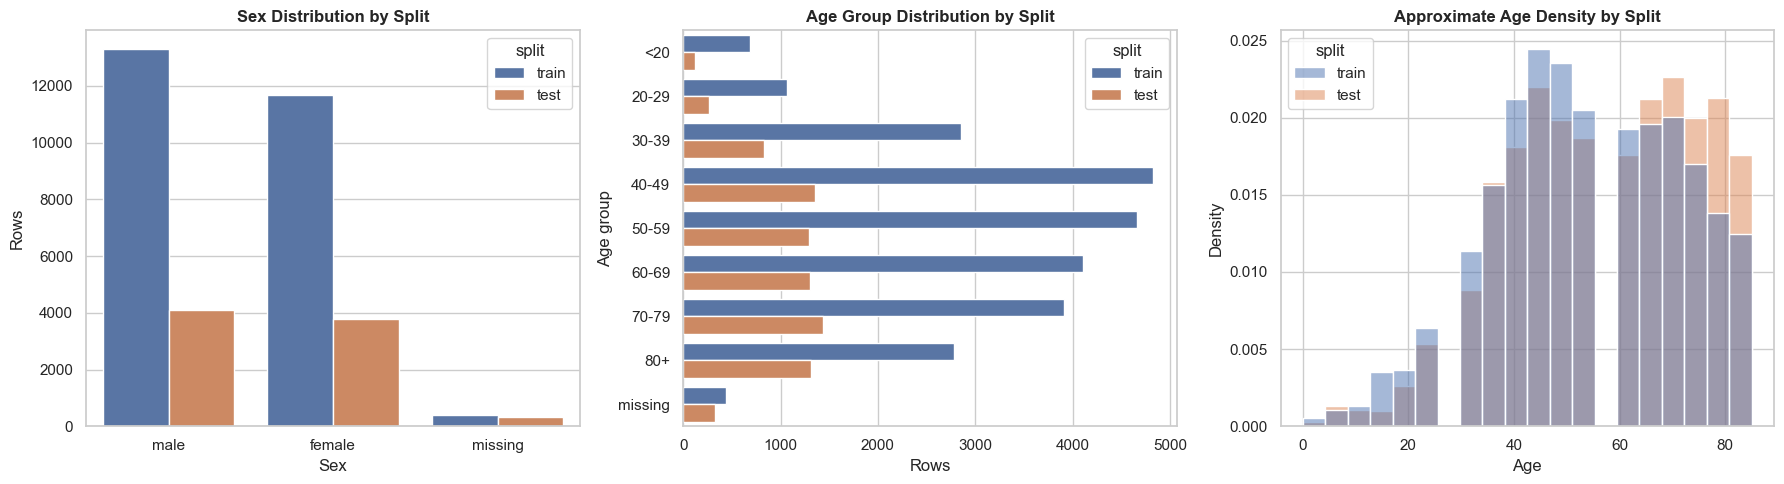

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="sex_clean", hue="split", order=df["sex_clean"].value_counts().index, ax=axes[0])
axes[0].set_title("Sex Distribution by Split")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Rows")

sns.countplot(data=df, y="age_group", hue="split", order=age_labels + ["missing"], ax=axes[1])
axes[1].set_title("Age Group Distribution by Split")
axes[1].set_xlabel("Rows")
axes[1].set_ylabel("Age group")

sns.histplot(data=df, x="age", hue="split", bins=20, common_norm=False, stat="density", ax=axes[2])
axes[2].set_title("Approximate Age Density by Split")
axes[2].set_xlabel("Age")

plt.tight_layout()
plt.show()

## Label Distribution by Age and Sex

Diagnosis is the prediction target, not a fairness attribute. We still inspect diagnosis distributions across age and sex because a group can be underrepresented overall or underrepresented for clinically important labels.

,split,diagnosis,n,pct_within_split
5,test,NV,2495,30.2865
7,test,UNK,2047,24.8483
4,test,MEL,1327,16.1083
1,test,BCC,975,11.8354
2,test,BKL,660,8.0117
0,test,AK,374,4.5399
6,test,SCC,165,2.0029
8,test,VASC,104,1.2624
3,test,DF,91,1.1046
14,train,NV,12875,50.8270


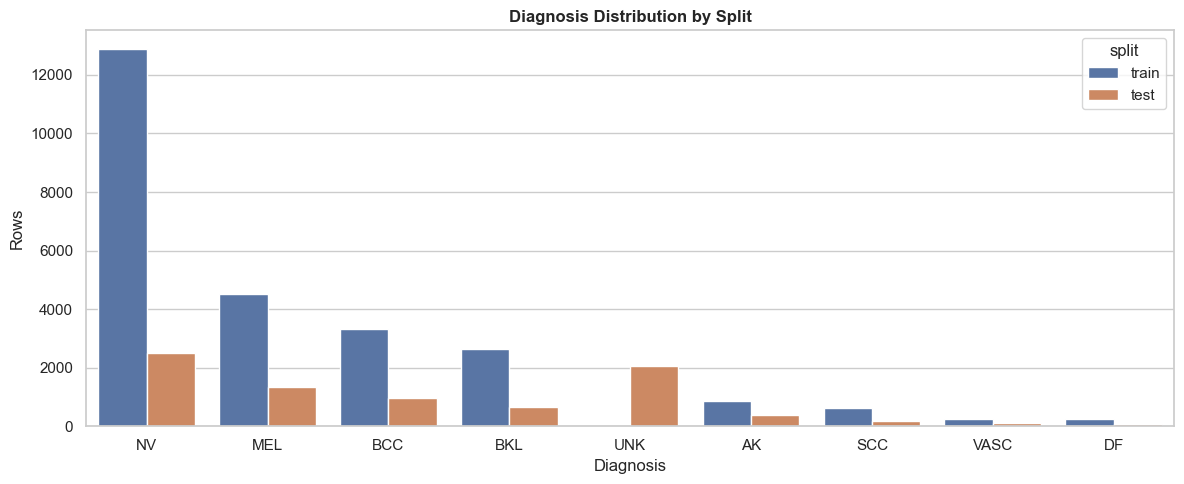

In [23]:
labeled = df[df["diagnosis"].notna()].copy()

diagnosis_summary = count_table(labeled, "diagnosis")
display(diagnosis_summary)

fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=labeled, x="diagnosis", hue="split", order=labeled["diagnosis"].value_counts().index, ax=ax)
ax.set_title("Diagnosis Distribution by Split")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

sex_clean,female,male,missing
diagnosis,,,
AK,46.8281,52.8258,0.3460
BCC,39.6329,60.1866,0.1806
BKL,43.2165,55.9070,0.8765
DF,48.9540,51.0460,0.0000
MEL,43.7859,54.4228,1.7912
NV,49.5456,48.3495,2.1049
SCC,32.3248,67.6752,0.0000
VASC,49.4071,50.5929,0.0000


age_group,20-29,30-39,40-49,50-59,60-69,70-79,80+,<20,missing
diagnosis,,,,,,,,,
AK,0.0000,2.1915,2.4221,13.2641,27.5663,31.8339,22.1453,0.2307,0.3460
BCC,0.6921,3.4908,8.8775,14.8059,20.3130,26.3015,25.2182,0.1204,0.1806
BKL,0.4573,3.8110,10.0991,16.3872,22.9802,27.7058,17.3399,0.2287,0.9909
DF,0.8368,12.5523,25.5230,25.1046,17.5732,9.6234,5.8577,2.9289,0.0000
MEL,1.3932,6.1477,13.9540,19.1287,19.6373,21.0747,16.6298,0.1548,1.8797
NV,7.4175,17.7010,27.0913,20.1398,11.7670,6.1670,2.2602,4.9942,2.4621
SCC,0.0000,0.4777,3.3439,9.2357,19.5860,32.9618,34.3949,0.0000,0.0000
VASC,3.9526,9.8814,19.3676,18.1818,10.2767,24.5059,7.9051,5.9289,0.0000


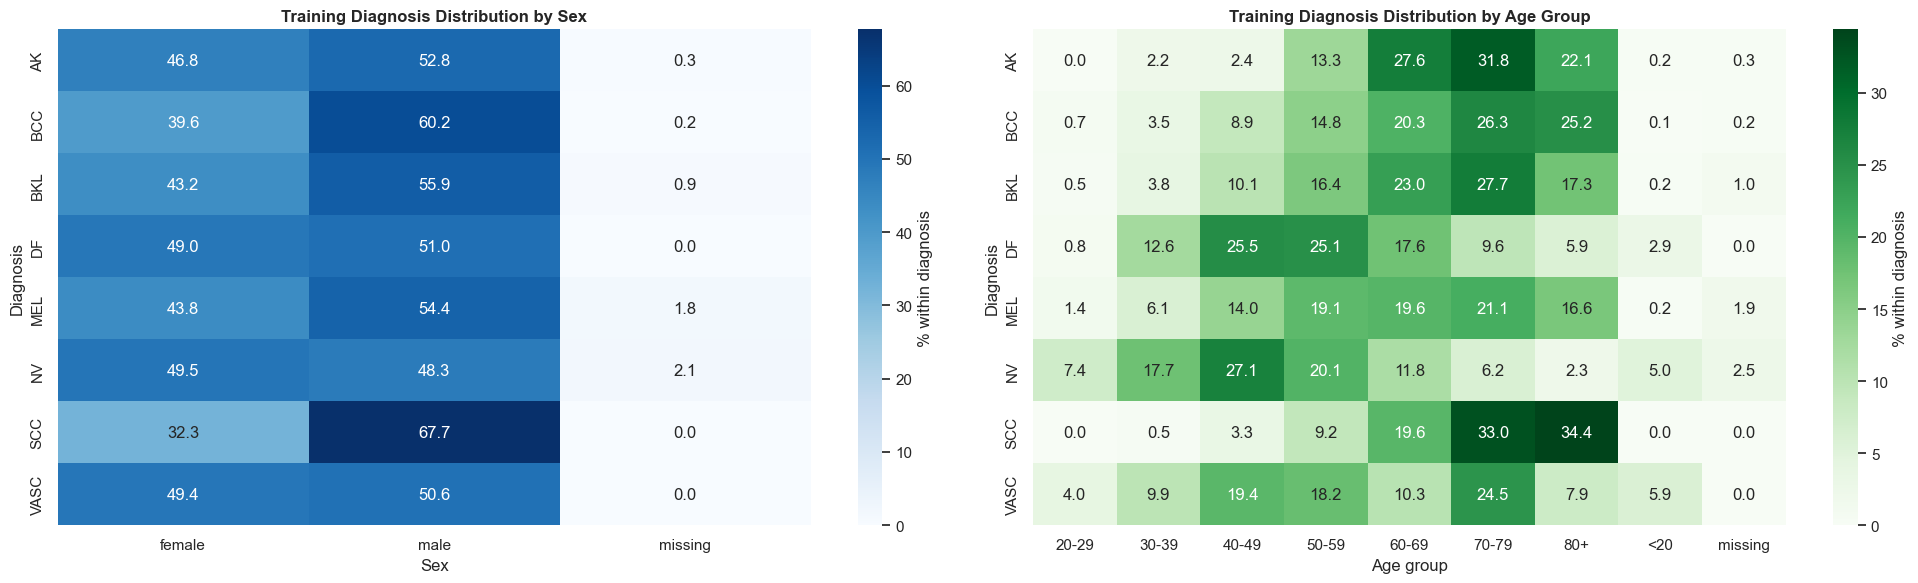

In [24]:
train_labeled = labeled[labeled["split"] == "train"].copy()

sex_by_dx = pd.crosstab(train_labeled["diagnosis"], train_labeled["sex_clean"], normalize="index") * 100
age_by_dx = pd.crosstab(train_labeled["diagnosis"], train_labeled["age_group"], normalize="index") * 100

display(sex_by_dx)
display(age_by_dx)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.heatmap(sex_by_dx, annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={"label": "% within diagnosis"})
axes[0].set_title("Training Diagnosis Distribution by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Diagnosis")

sns.heatmap(age_by_dx, annot=True, fmt=".1f", cmap="Greens", ax=axes[1], cbar_kws={"label": "% within diagnosis"})
axes[1].set_title("Training Diagnosis Distribution by Age Group")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Diagnosis")

plt.tight_layout()
plt.show()

## Fairness Metrics: Representation Balance

These are representation fairness metrics for `sex_clean`, `age_group`, and their intersection `age_x_sex`.

- **Min/max representation ratio** closer to 1 means more balanced.
- Values below **0.8** are a practical warning threshold.
- **Normalized entropy** closer to 1 means more even group representation.
- **Gini concentration** closer to 0 means more even representation.

In [25]:
def normalized_entropy(proportions):
    p = np.asarray(proportions, dtype=float)
    p = p[p > 0]
    if len(p) <= 1:
        return 1.0
    return float(-(p * np.log(p)).sum() / np.log(len(p)))

def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    if len(x) == 0 or np.isclose(x.sum(), 0):
        return np.nan
    n = len(x)
    return float((2 * np.arange(1, n + 1) @ x) / (n * x.sum()) - (n + 1) / n)

def representation_metrics(data, group_col):
    rows = []
    for split_name, split_df in data.groupby("split"):
        shares = split_df[group_col].value_counts(normalize=True, dropna=False)
        min_share = shares.min()
        max_share = shares.max()
        rows.append({
            "split": split_name,
            "attribute": group_col,
            "n_groups": len(shares),
            "min_share_pct": min_share * 100,
            "max_share_pct": max_share * 100,
            "min_to_max_ratio": min_share / max_share if max_share else np.nan,
            "max_disparity_pp": (max_share - min_share) * 100,
            "normalized_entropy": normalized_entropy(shares.values),
            "gini_concentration": gini(shares.values),
            "smallest_group": shares.idxmin(),
            "largest_group": shares.idxmax(),
        })
    return pd.DataFrame(rows)

fairness_cols = ["sex_clean", "age_group", "age_x_sex"]
balance_metrics = pd.concat([representation_metrics(df, col) for col in fairness_cols], ignore_index=True)
display(balance_metrics.sort_values(["attribute", "split"]))

,split,attribute,n_groups,min_share_pct,max_share_pct,min_to_max_ratio,max_disparity_pp,normalized_entropy,gini_concentration,smallest_group,largest_group
2,test,age_group,9,1.5052,17.4071,0.0865,15.9019,0.9144,0.2946,<20,70-79
3,train,age_group,9,1.7252,19.0715,0.0905,17.3463,0.9103,0.3222,missing,40-49
4,test,age_x_sex,21,0.0243,11.5926,0.0021,11.5683,0.8767,0.4344,70-79 | missing,70-79 | male
5,train,age_x_sex,19,0.1026,10.0825,0.0102,9.9799,0.9082,0.3793,missing | female,70-79 | male
0,test,sex_clean,3,4.1151,49.9150,0.0824,45.8000,0.7604,0.3053,missing,male
1,train,sex_clean,3,1.5159,52.4496,0.0289,50.9336,0.6910,0.3396,missing,male


## Group Parity Tables

In [26]:
def group_parity_table(data, group_col):
    counts = data.groupby(["split", group_col]).size().rename("n").reset_index()
    counts["share"] = counts["n"] / counts.groupby("split")["n"].transform("sum")

    pivot = counts.pivot(index=group_col, columns="split", values=["n", "share"]).fillna(0)
    pivot.columns = [f"{metric}_{split}" for metric, split in pivot.columns]
    pivot = pivot.reset_index()

    overall = data[group_col].value_counts(normalize=True).rename("overall_share")
    pivot = pivot.merge(overall, left_on=group_col, right_index=True, how="left")
    pivot["uniform_share"] = 1 / data[group_col].nunique(dropna=False)

    for split in ["train", "test"]:
        share_col = f"share_{split}"
        if share_col in pivot:
            pivot[f"{split}_ratio_to_uniform"] = pivot[share_col] / pivot["uniform_share"]
            pivot[f"{split}_ratio_to_overall"] = pivot[share_col] / pivot["overall_share"]

    if {"share_train", "share_test"}.issubset(pivot.columns):
        pivot["test_minus_train_pp"] = (pivot["share_test"] - pivot["share_train"]) * 100
        pivot["test_to_train_ratio"] = pivot["share_test"] / pivot["share_train"].replace(0, np.nan)

    ratio_cols = [c for c in pivot.columns if c.endswith("ratio_to_uniform")]
    pivot["underrepresented_vs_uniform"] = pivot[ratio_cols].lt(0.8).any(axis=1)
    return pivot.sort_values("overall_share", ascending=False)

for column in fairness_cols:
    print(f"\n{column.upper()} parity table")
    display(group_parity_table(df, column))


SEX_CLEAN parity table


,sex_clean,n_test,n_train,share_test,share_train,overall_share,uniform_share,train_ratio_to_uniform,train_ratio_to_overall,test_ratio_to_uniform,test_ratio_to_overall,test_minus_train_pp,test_to_train_ratio,underrepresented_vs_uniform
1,male,"4,112.0000","13,286.0000",0.4992,0.5245,0.5183,0.3333,1.5735,1.0120,1.4975,0.9631,-2.5345,0.9517,False
0,female,"3,787.0000","11,661.0000",0.4597,0.4603,0.4602,0.3333,1.3810,1.0003,1.3791,0.9989,-0.0646,0.9986,False
2,missing,339.0000,384.0000,0.0412,0.0152,0.0215,0.3333,0.0455,0.7038,0.1235,1.9106,2.5991,2.7146,True



AGE_GROUP parity table


,age_group,n_test,n_train,share_test,share_train,overall_share,uniform_share,train_ratio_to_uniform,train_ratio_to_overall,test_ratio_to_uniform,test_ratio_to_overall,test_minus_train_pp,test_to_train_ratio,underrepresented_vs_uniform
2,40-49,"1,349.0000","4,831.0000",0.1638,0.1907,0.1841,0.1111,1.7164,1.0359,1.4738,0.8895,-2.6962,0.8586,False
3,50-59,"1,296.0000","4,659.0000",0.1573,0.1839,0.1774,0.1111,1.6553,1.0368,1.4159,0.8868,-2.6605,0.8553,False
4,60-69,"1,305.0000","4,111.0000",0.1584,0.1623,0.1613,0.1111,1.4606,1.0059,1.4257,0.9819,-0.3879,0.9761,False
5,70-79,"1,434.0000","3,916.0000",0.1741,0.1546,0.1594,0.1111,1.3913,0.9700,1.5666,1.0922,1.9478,1.1260,False
6,80+,"1,307.0000","2,778.0000",0.1587,0.1097,0.1217,0.1111,0.9870,0.9012,1.4279,1.3038,4.8987,1.4467,False
1,30-39,829.0000,"2,850.0000",0.1006,0.1125,0.1096,0.1111,1.0126,1.0266,0.9057,0.9182,-1.1879,0.8944,False
0,20-29,268.0000,"1,065.0000",0.0325,0.0420,0.0397,0.1111,0.3784,1.0588,0.2928,0.8193,-0.9511,0.7738,True
7,<20,124.0000,684.0000,0.0151,0.0270,0.0241,0.1111,0.2430,1.1218,0.1355,0.6254,-1.1950,0.5574,True
8,missing,326.0000,437.0000,0.0396,0.0173,0.0227,0.1111,0.1553,0.7590,0.3562,1.7410,2.2321,2.2939,True



AGE_X_SEX parity table


,age_x_sex,n_test,n_train,share_test,share_train,overall_share,uniform_share,train_ratio_to_uniform,train_ratio_to_overall,test_ratio_to_uniform,test_ratio_to_overall,test_minus_train_pp,test_to_train_ratio,underrepresented_vs_uniform
14,70-79 | male,955.0000,"2,554.0000",0.1159,0.1008,0.1045,0.0435,2.3190,0.9645,2.6663,1.1090,1.5101,1.1498,False
5,40-49 | female,784.0000,"2,544.0000",0.0952,0.1004,0.0991,0.0435,2.3099,1.0130,2.1889,0.9600,-0.5262,0.9476,False
12,60-69 | male,704.0000,"2,341.0000",0.0855,0.0924,0.0907,0.0435,2.1256,1.0188,1.9655,0.9421,-0.6959,0.9247,False
8,50-59 | female,688.0000,"2,330.0000",0.0835,0.0920,0.0899,0.0435,2.1156,1.0231,1.9209,0.9289,-0.8467,0.9080,False
9,50-59 | male,605.0000,"2,329.0000",0.0734,0.0919,0.0874,0.0435,2.1147,1.0520,1.6891,0.8403,-1.8503,0.7988,False
6,40-49 | male,560.0000,"2,287.0000",0.0680,0.0903,0.0848,0.0435,2.0765,1.0645,1.5635,0.8015,-2.2307,0.7529,False
17,80+ | male,738.0000,"1,755.0000",0.0896,0.0693,0.0743,0.0435,1.5935,0.9329,2.0605,1.2063,2.0302,1.2930,False
11,60-69 | female,601.0000,"1,770.0000",0.0730,0.0699,0.0706,0.0435,1.6071,0.9893,1.6780,1.0329,0.3080,1.0441,False
3,30-39 | female,460.0000,"1,653.0000",0.0558,0.0653,0.0629,0.0435,1.5009,1.0367,1.2843,0.8871,-0.9417,0.8557,False
13,70-79 | female,477.0000,"1,362.0000",0.0579,0.0538,0.0548,0.0435,1.2367,0.9815,1.3318,1.0569,0.4134,1.0769,False


## Train/Test Shift for Age and Sex

In [27]:
def js_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))

    return float(np.sqrt(0.5 * kl(p, m) + 0.5 * kl(q, m)))

def split_shift_metrics(data, group_col):
    train_dist = data.loc[data["split"] == "train", group_col].value_counts(normalize=True)
    test_dist = data.loc[data["split"] == "test", group_col].value_counts(normalize=True)
    groups = sorted(set(train_dist.index) | set(test_dist.index))
    p = train_dist.reindex(groups, fill_value=0).values
    q = test_dist.reindex(groups, fill_value=0).values
    diff = np.abs(p - q)
    return {
        "attribute": group_col,
        "total_variation_distance": 0.5 * diff.sum(),
        "jensen_shannon_distance": js_distance(p, q),
        "max_abs_diff_pp": diff.max() * 100,
        "largest_shift_group": groups[int(diff.argmax())],
    }

shift_metrics = pd.DataFrame([split_shift_metrics(df, col) for col in fairness_cols])
display(shift_metrics.sort_values("total_variation_distance", ascending=False))

,attribute,total_variation_distance,jensen_shannon_distance,max_abs_diff_pp,largest_shift_group
2,age_x_sex,0.0973,0.1194,2.8685,80+ | female
1,age_group,0.0908,0.1017,4.8987,80+
0,sex_clean,0.0260,0.0687,2.5991,missing


## Intersectional View: Age x Sex

split       test               train              
sex_clean female male missing female  male missing
age_group                                         
20-29        145  120       3    617   448       0
30-39        460  369       0   1653  1197       0
40-49        784  560       5   2544  2287       0
50-59        688  605       3   2330  2329       0
60-69        601  704       0   1770  2341       0
70-79        477  955       2   1362  2554       0
80+          569  738       0   1023  1755       0
<20           63   61       0    336   348       0
missing        0    0     326     26    27     384

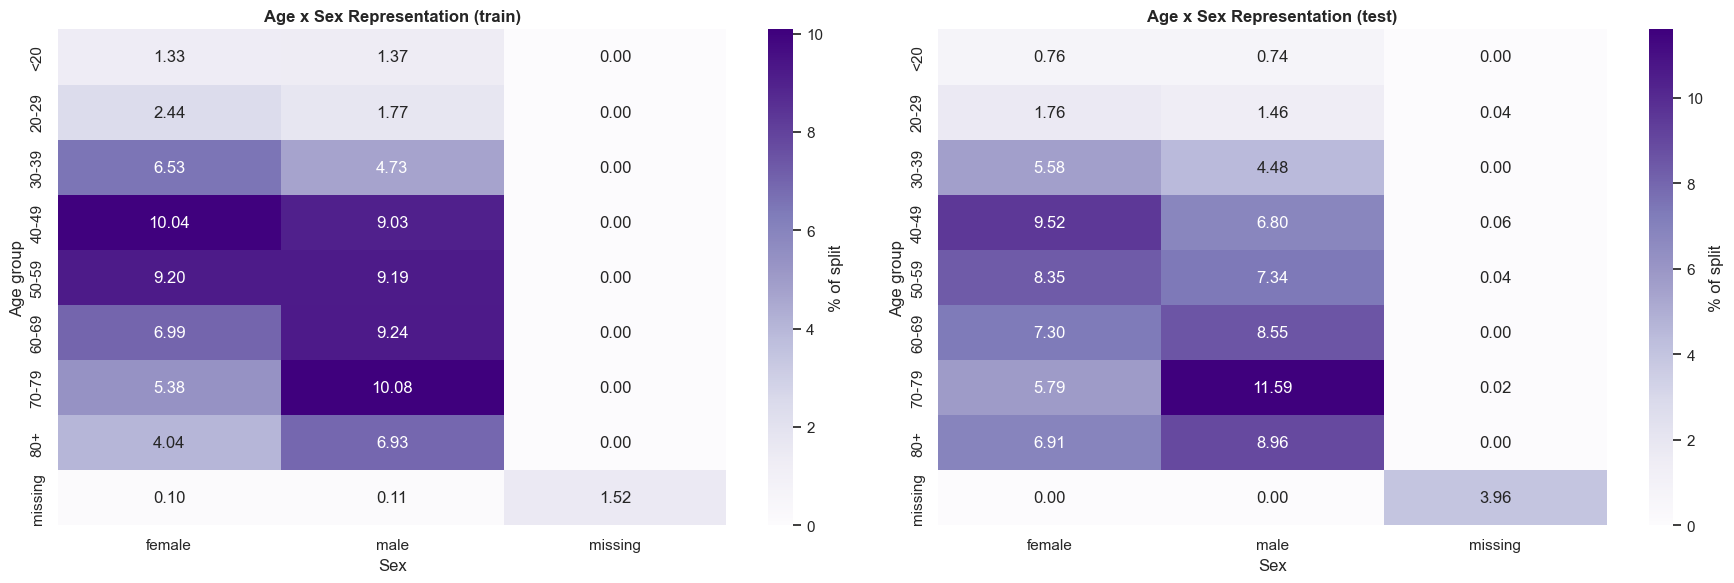

In [28]:
age_sex_table = pd.crosstab(df["age_group"], [df["split"], df["sex_clean"]])
display(age_sex_table)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, split in zip(axes, ["train", "test"]):
    split_df = df[df["split"] == split]
    heat = pd.crosstab(split_df["age_group"], split_df["sex_clean"], normalize="all") * 100
    heat = heat.reindex(age_labels + ["missing"])
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="Purples", ax=ax, cbar_kws={"label": "% of split"})
    ax.set_title(f"Age x Sex Representation ({split})")
    ax.set_xlabel("Sex")
    ax.set_ylabel("Age group")
plt.tight_layout()
plt.show()

## Candidate Human Review Queue

This queue is useful for the human-in-the-loop system idea. It prioritizes training samples from underrepresented age/sex groups and rare diagnosis-by-group combinations. The UI could show these rows first for label verification.

In [29]:
train_df = df[df["split"] == "train"].copy()

group_counts = train_df["age_x_sex"].value_counts()
group_share = train_df["age_x_sex"].value_counts(normalize=True)
uniform_share = 1 / train_df["age_x_sex"].nunique(dropna=False)

train_df["age_x_sex_n"] = train_df["age_x_sex"].map(group_counts)
train_df["age_x_sex_share"] = train_df["age_x_sex"].map(group_share)
train_df["age_x_sex_ratio_to_uniform"] = train_df["age_x_sex_share"] / uniform_share

dx_group_counts = train_df.groupby(["diagnosis", "age_x_sex"]).size().rename("diagnosis_age_x_sex_n")
train_df = train_df.merge(dx_group_counts, on=["diagnosis", "age_x_sex"], how="left")

train_df["review_reason"] = np.select(
    [
        train_df["sex_clean"].eq("missing") | train_df["age_group"].eq("missing"),
        train_df["age_x_sex_ratio_to_uniform"].lt(0.8),
        train_df["diagnosis_age_x_sex_n"].lt(25),
    ],
    [
        "missing age or sex metadata",
        "underrepresented age x sex group",
        "rare diagnosis within age x sex group",
    ],
    default="not prioritized",
)

review_queue = (
    train_df[train_df["review_reason"] != "not prioritized"]
    .sort_values(["review_reason", "age_x_sex_ratio_to_uniform", "diagnosis_age_x_sex_n"], ascending=[True, True, True])
    [[
        "image", "diagnosis", "age", "age_group", "sex_clean", "age_x_sex",
        "age_x_sex_n", "age_x_sex_share", "age_x_sex_ratio_to_uniform",
        "diagnosis_age_x_sex_n", "review_reason",
    ]]
)

print(f"Candidate training rows for human review: {len(review_queue):,}")
display(review_queue.head(50))

Candidate training rows for human review: 3,489


,image,diagnosis,age,age_group,sex_clean,age_x_sex,age_x_sex_n,age_x_sex_share,age_x_sex_ratio_to_uniform,diagnosis_age_x_sex_n,review_reason
2508,ISIC_0014897_downsampled,MEL,NaN,missing,female,missing | female,26,0.0010,0.0195,3,missing age or sex metadata
2517,ISIC_0014912_downsampled,MEL,NaN,missing,female,missing | female,26,0.0010,0.0195,3,missing age or sex metadata
2523,ISIC_0014922_downsampled,MEL,NaN,missing,female,missing | female,26,0.0010,0.0195,3,missing age or sex metadata
304,ISIC_0000340,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata
310,ISIC_0000346,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata
311,ISIC_0000347,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata
312,ISIC_0000348,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata
313,ISIC_0000349,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata
314,ISIC_0000350,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata
317,ISIC_0000353,NV,NaN,missing,female,missing | female,26,0.0010,0.0195,23,missing age or sex metadata


## Bias Risk Summary

Use this table in the project report to describe which age/sex groups may need extra review, group-aware sampling, or subgroup-specific evaluation.

In [30]:
risk_summary = balance_metrics.merge(shift_metrics, on="attribute", how="left")
risk_summary["representation_warning"] = np.select(
    [
        risk_summary["min_to_max_ratio"].lt(0.5),
        risk_summary["min_to_max_ratio"].lt(0.8),
    ],
    ["high imbalance", "moderate imbalance"],
    default="balanced by ratio threshold",
)
risk_summary["split_shift_warning"] = np.select(
    [
        risk_summary["total_variation_distance"].ge(0.05),
        risk_summary["total_variation_distance"].ge(0.02),
    ],
    ["review train/test shift", "small train/test shift"],
    default="low train/test shift",
)

display(risk_summary[[
    "split", "attribute", "n_groups", "smallest_group", "largest_group",
    "min_to_max_ratio", "max_disparity_pp", "normalized_entropy",
    "representation_warning", "total_variation_distance", "largest_shift_group",
    "split_shift_warning",
]].sort_values(["attribute", "split"]))

,split,attribute,n_groups,smallest_group,largest_group,min_to_max_ratio,max_disparity_pp,normalized_entropy,representation_warning,total_variation_distance,largest_shift_group,split_shift_warning
2,test,age_group,9,<20,70-79,0.0865,15.9019,0.9144,high imbalance,0.0908,80+,review train/test shift
3,train,age_group,9,missing,40-49,0.0905,17.3463,0.9103,high imbalance,0.0908,80+,review train/test shift
4,test,age_x_sex,21,70-79 | missing,70-79 | male,0.0021,11.5683,0.8767,high imbalance,0.0973,80+ | female,review train/test shift
5,train,age_x_sex,19,missing | female,70-79 | male,0.0102,9.9799,0.9082,high imbalance,0.0973,80+ | female,review train/test shift
0,test,sex_clean,3,missing,male,0.0824,45.8000,0.7604,high imbalance,0.0260,missing,small train/test shift
1,train,sex_clean,3,missing,male,0.0289,50.9336,0.6910,high imbalance,0.0260,missing,small train/test shift


## How This Supports a Training-Time Human Review UI

The `review_queue` table can be used as the backend source for a UI that asks reviewers to verify labels before or during training.

Recommended UI fields:

- Image id and, once downloaded, the lesion image.
- Current diagnosis label.
- Current age and sex metadata.
- Review reason, such as underrepresented age x sex group or rare diagnosis within age x sex group.
- Reviewer actions: confirm label, correct label, mark uncertain, request second review, exclude from training.

Recommended training intervention:

- Before training: require review for high-priority queue items.
- During training: increase sampling weight for underrepresented age/sex intersections.
- After each validation pass: evaluate performance by age group, sex, and age x sex. Send high-error groups back to the review queue.